# `TP Apprentissage par renforcement 2/2`

Dans cette séance, nous allons utiliser des implémentations existantes d'algorithmes d'apprentissage par renforcement (par exemple DQN), avec la librairire stable-baselines, et voir comment arriver à régler
les paramètres de l'algorithme pour améliorer les performances.

Il y a d'abord un certain nombre de choses à installer (décommentez les lignes ci-dessous):

## `Deep Q-Network (DQN)`

:::

Le DQN est un algorithme qui combine pour résoudre des problèmes complexes de prise de décision:

 - l'apprentissage par renforcement avec 
 - l'apprentissage profond 

Le DQN “classique” est, comme le Q-learning dont il dérive, un algorithme off‑policy, la mise à jour du réseau utilise une cible greedy sur l’état suivant :

 - $y_{t} = R_{t}+γ.max_{a'}Q_{\theta^-}(S_{t+1},a')$

DQN surmonte bon nombre des limites du Q-Learning de base, grace à sa capacité à apprendre des tâches complexes à partir d'entrées à grandes dimensions qui en fait un outil puissant pour résoudre des problèmes du monde réel comme le jeu, la robotique et la conduite autonome.

:::

:::

__`Caractéristiques principales`__

- Utilise un réseau de neurones profond pour estimer les valeurs Q.
- Emploie d'une mémoire de relecture pour stocker et échantillonner les expériences passées.
- Utilisation d'un réseau cible pour stabiliser l’apprentissage.

:::

:::

__`Q-learning off-policy`__, 

 - Veut dire que ce que l’algorithme apprend (la politique cible) n’est pas nécessairement la même chose que ce que l’agent fait réellement pendant qu’il collecte des données.

 - L'algorithme apprend la politique optimale indépendamment de la politique suivie par l’agent. 

 - Pendant l’exploration, l’agent agit souvent avec une politique ϵ-greedy, la plupart du temps l’action avec le meilleur $Q(s,a)$, mais parfois une action aléatoire pour explorer.

 - lorsd la mise à jour avec Q-learning, la cible utilise $max_{a^′}Q(S_{t+1},a )$ qui correspond à la politique greedy idéale (choix de l’action qui maximise Q).

En d’autres termes, même si l’agent, en pratique, suit une politique “greedy + exploration”, la mise à jour suppose que dans le futur on jouera toujours l’action optimale.


__`En SARSA (on‑policy)`__ :    

 - la cible est $R+γQ(S_{t+1},A_{t+1})$, où $A_{t+1}$ est l’action réellement échantillonnée par la politique ϵ-greedy.

 - On y apprend donc la valeur de la politique effectivement suivie (greedy + exploration),
 
 - Contrairement qu'avec Q-learning où l'on apprend la valeur de la politique greedy “idéale”, même si l’agent agit autrement pendant l’apprentissage.

:::

## `Concepts clés du deep learning associé à la fonction Q`

:::

`Approximation de la fonction Q`: 

- Ne stocke pas dans une table les valeurs de Q pour chaque paire (action/état), 
- Le DQN utilise un réseau neuronal pour approximer les valeurs Q:

  - L'entrée du réseau est l'état, 
  - La sortie est un ensemble de valeurs Q pour toutes les actions possibles.

:::

## `Équation de Bellman et Deep Q-Network ` 

__`Mathématiquement`__.   

$Q(S_t,A_t;θ)$ est la valeur de la fonction $Q_θ:S×A→R$ définie par le réseau de neurones, évaluée au point $(S_t,A_t)$.

__`Fonction paramétrique`__.  

 - On définit une famille de fonctions $\{Q_θ\}_{θ∈ R^d}$ où θ est le vecteur de tous les poids et biais du réseau.
 - Pour un état $s∈S$ et une action $a∈A$, 
 - la valeur $Q_θ(s,a) = Q(s,a;θ)$ est un scalaire 
 - $Q_θ(s,a)$ approxime l’espérance mathématique du retour futur d'une politique greedy par rapport à $Q_θ$

$$Q_\theta(s, a) \approx \mathbb{E}\left[ \sum_{k=0}^{\infty} \gamma^{k} R_{t+k+1} \,\bigg|\, S_t = s,\ A_t = a,\ \pi_\theta \right] $$

__`Dans la mise à jour du DQN (Deep Q-Network)`__

 - On cherche $θ$ tel que $Q_θ$ satisfasse l’équation de Bellman optimale. 
 - On définit la cible $y_t = R_t + γ.max_{a'}.Q(S_{t+1},a',\theta^-)$
 - puis on minimise (en pratique par SGD) l’erreur quadratique $L(θ)=E[(y_t−Q(S_t,A_t;θ))^2]$
   - E[⋅] est la moyenne sur toutes les transitions $(S_t,A_t,R_t,S_{t+1})$ qu’on pourrait voir.
   - L'espérance est remplacée par par une moyenne sur un mini‑batch échantillonné du replay buffer.    
 - Le gradient $∇_θL(θ)$ se calcule en dérivant $Q(S_t,A_t;θ)$ par rapport à θ; 
 - on met ensuite à jour $θ←θ−α∇_θL(θ)$ ce qui ajuste la fonction $Q_θ$ pour se rapprocher du point fixe de Bellman.

__`Le gradient et la mise à jour des poids`__

 - On veut choisir θ qui minimise $(θ)$, ce que fait la descente de gradient : $ ∇_θL(θ)= \Large \frac{∂θ} {∂L(θ)}$.     
 - $L(θ)$ dépend de $θ$ uniquement via $Q(S_t,A_t;θ)$, dériver L revient à dériver la sortie du réseau par rapport à ses poids.

:::

<img src="/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_APPAUT/TP4/img/dqn.png" alt="Structure d'un DQN" width="600"/>

:::

:::

## __`L'algorithme DQN (Deep Q-Network):`__ 

DQN possède deux réseaux de neurones distincts $(\theta,\theta^-)$ qui approximent la fonction Q.

La règle de mise à jour pour l'algorithme DQN est basée sur l'équation de Bellman, similaire à Q-Learning :

$ \large Q(S_t, A_t) \leftarrow  Q(S_t, A_t) + \alpha * [ + \gamma * max_a Q(S_{t+1}, a;\theta^-) - Q(S_t, A_t;\theta)]$

 - $\theta$ sont les poids du réseau Q principal,
 - $\theta^-$ sont les poids du réseau Q cible,
 - $S$ est l'état actuel,
 - $A$ est l'action entreprise,
 - $R$ est  la récompense reçue,
 - $S'$ est le prochain état,
 - $max_{⁡A'} Q(S',A')$ est la valeur Q maximale pour l'état suivant.

 :::

 :::

__`Réseau principal`__.  

 - C’est le réseau $Q_θ$ que l’on met à jour par descente de gradient à chaque itération d’apprentissage.
 - Il sert à choisir les actions pendant l’interaction avec l’environnement (politique ϵ-greedy ou greedy)
 - Il apparaît dans le terme $Q(S_t,A_t;θ)$ que l’on corrige dans ta règle de mise à jour.

__`Réseau cible`__

 - C’est une copie figée du réseau principal, notée $Q_{θ^−}$, mis à jour moins souvent (tous les N pas).
 - Sert à calculer la cible de Bellman $R+γ.max_a.Q(S_{t+1},a;θ^−)$ lors l’apprentissage du réseau principal.        
 - Ceci évite que la “cible” bouge en même temps que les paramètres que l’on entraine et stabilise l’algorithme.
 - S'effectue en conjonction avec d'autres techniques comme la relecture d'expérience (Experience Replay).

:::

:::

__`Relecture de l'expérience`__ 

- Le modèle DQN pour stabiliser l'apprentissage utilise un `tampon de mémoire de relecture`. 
- Ce tampon de mémoire stocke les expériences (état, action, récompense, état suivant). 
- Le réseau est formé sur des mini-lots aléatoires d'expériences de ce tampon, 
- Ce mécanisme rompt la corrélation des expériences consécutives, améliorant l'efficacité de l'échantillon.

:::

:::
$ \large Q(S_t, A_t) \leftarrow  Q(S_t, A_t) + \alpha * [ + \gamma * max_a Q(S_{t+1}, a) - Q(S_t, A_t)]$

 - Nouvelle estimation de la Q-value :  $Q(S_t, A_t)$
 - Former estimation Q-value : $ Q(S_t, A_t)$
 - Learning rate  : $\large \alpha$ 
 - Immediate reward : $R_t+1$ 
 - Estimation pondérée de la Q-value au prochain état : $\gamma * max_a Q(S_{t+1}, a)$

:::



### __`Schéma de l'algorithme DQN (Deep Q-Network)`__

`L'algorithme Deep Q-Learning procède en deux phases: `

- __`Échantillonnage`__: effectue des actions et stocke les tuples d'expérience dans la mémoire de relecture.
- __`Apprentissage`__ : sélectionne un petit lot au hasard et apprentissage par mise à jour via la descente du gradient.


<img src="/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_APPAUT/TP4/img/sampling-training.png" alt="Structure du DQN" width="600"/>

## `Experience Replay`

:::
__`Oubli`__ 

   - Habituellement, lors de l'apprentissage par renforcement, l'agent interagit avec l'environnement, et obtient des expériences (état, action, récompense et prochain état), à partir desquels il apprend, met à jour le réseau neuronal et rejette ces données, ce qui n'est pas très efficace.

  - Le problème que nous avons si nous donnons des échantillons séquentiels d'expériences à notre réseau neuronal est qu'il a tendance à oublier les expériences précédentes à mesure qu'il obtient de nouvelles expériences.

__` Experience Replay`__

  - Expérience replay ou réutilisation de l'expérience, consiste à créer un tampon qui stocke les tuples.
  - Le réseau utilise ce tampon de relecture qui enregistre des échantillons d'expérience.
  - Le tampon permet au réseau de ne pas apprendre uniquement de ce qu'il a fait immédiatement avant.        
  - La relecture de ce tampon permet d'utiliser efficacement les expériences issues de l'apprentissage.   

:::

:::

Experience Replay permet à l'agent d'apprendre à partir de la même expérience à plusieurs reprises.

 - Initialize replay memory D to capacity N
 - Store transition $\large (\phi_t, a_t, r_t,\phi_{t+1} ）\small \text{from } D$
 - Sample random minibatch of transitions $\large (\phi_j, a_j, r_j,\phi_{j+1} ）\small \text{from } D $

In [1]:
%pip -q install gymnasium
%pip -q install 'stable-baselines3[extra]'
%pip -q install tensorboard

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
from stable_baselines3 import DQN
from stable_baselines3.common.logger import configure

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [3]:
import pandas as pds
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym

In [4]:
# pour lire des videos locales facilement
from tqdm import tqdm
import matplotlib.animation as animation
import matplotlib.cm as cm
import torch 
import os

from base64 import b64encode
from IPython.display import HTML


def play_video(v_path,width=400):
      mp4 = open(v_path,'rb').read()
      data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
      return HTML("""
          <video width:%d controls>
          <source src="%s" type="video/mp4">
          </video>
          """ % (width,data_url))

# images sauvées pendant la simulation -> video
def make_video(images,outfile="movie.mp4"):
    fig = plt.figure()
    img_frames = []
    for img in tqdm(images):
        img= np.array(img)
        if len(img.shape)==4:
            img = np.squeeze(img, axis=0)  
        img_frames.append([plt.imshow(img,cmap=cm.Greys_r,animated=True)])
    ani = animation.ArtistAnimation(fig, img_frames, interval=50, blit=True,repeat_delay=1000)
    if os.path.exists(outfile):
        os.remove(outfile)
    ani.save(outfile)
    plt.close(fig)
    return
    

# __`Mountain Car`__

- Le processus de décision markovien (MDP) d'une voiture est placée aléatoirement au fond d'une vallée sinusoïdale est déterministe.    
- Les seules actions possibles sont les accélérations, qui peuvent être appliquées à la voiture dans les deux sens.    
- L'objectif du MDP est d'accélérer stratégiquement la voiture pour atteindre l'état final, au sommet de la colline de droite.    
- Cette version du domaine de la voiture en montagne dans Gymnasium est celle avec des actions discrètes.

<img src="/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_APPAUT/TP4/img/mountain_car.gif" alt="MountainCar" width="300"/>

Signification des hyper-paramètres: (voir aussi https://stable-baselines3.readthedocs.io/en/master/modules/dqn.html)

Nous allons tenter de résoudre le problème suivant: une voiture essaie de monter une pente, mais son moteur n'est pas assez puissant pour y aller directement:

Ce problème fait partie des environnements implémentés dans OpenAI gym

https://gymnasium.farama.org/environments/classic_control/mountain_car/

### __`Espace d'observation`__
:::

| Numéro | Observation                               | Min   | Max  | Unité        |
| ------ | ----------------------------------------- | ----- | ---- | ------------ |
| 0      | position de la voiture le long de l'axe x | -1,2  | 0,6  | position (m) |
| 1      | vitesse de la voiture                     | -0,07 | 0,07 | vitesse (v)  |

:::

### __`Espace d'action`__ 
:::

Il existe 3 actions déterministes discrètes :

 - 0 : Accélérer vers la gauche
 - 1 : N'accélérez pas
 - 2 : Accélérez vers la droite

:::

### __`Dynamique de transition`__
:::
$vitesse_{t+1} = vitesse_{t} + (action - 1) * force - cos(3 * position_t ) * gravité$.    
$position_{t+1} = position_t + vitesse_{t+1}$

- force = 0,001 
- gravité = 0,0025. 

Les collisions aux extrémités sont inélastiques, la vitesse étant nulle lors de l'impact avec le mur. 

:::

In [5]:
import os
from stable_baselines3.common.logger import configure

def reset_logger(tmp_path):
    file_path = os.path.join(tmp_path, 'progress.csv')
    if os.path.exists(file_path):
        os.remove(os.path.join(tmp_path, 'progress.csv'))
    new_logger = configure(tmp_path, ["csv"])
    return  new_logger

In [6]:
def display_curve(log ):
    
    fig, ax = plt.subplots(1,2)
    plt.style.use('fivethirtyeight')
    plt.rcParams["figure.figsize"] = [13,4]
    plt.rcParams['font.size'] = 6
    plt.rcParams["figure.autolayout"] = True
    
    ax[0].set_title("Reward moyen")
    ax[0].plot(log['time/total_timesteps'], log['rollout/ep_rew_mean'], label="rew_mean",linewidth=1)
    
    plt.xlabel("Iterations")
    plt.ylabel("Loss")

    plt.title("Nombre d’updates")
    ax[1].plot(log['time/total_timesteps'], log['train/n_updates'], label="Update",linewidth=1)
    plt.xlabel("Iterations")
    plt.ylabel("Training Updates")
    ax[1].legend(loc='best')

    fig.tight_layout()
    plt.show()
    return

__`A faire`__:

Les parametres par défaut ne sont pas adaptés au problème ici, et il faut donc essayer de changer :

- la taille du memory replay (pas trop gros)
- du coup quel autre paramètre faut-il changer ? réponse learning_starts + target update interval
- le perceptron de départ n'a pas assez de paramètres: taille de la/des couches cachées
- relever le learning rate si rien ne se passe (10^n en augmentant n)
- taille des batchs + train freq (32,64,128) // (4,8,16)
- gradient steps: mettre 8
- seulement quand le training commence à être mieux allonger le nb de steps de l'entrainement


`buffer_size`: taille de la mémoire (memory replay)  

`exploration_final_eps/initial/fraction:` 
 - `Epsilon` décide la probabilité d'exploration au hasard peut être dynamique: 
 - Il démarre avec une valeur (initial), puis est diminué régulièrement (en * par fraction), jusqu'à une valeur finale constante.

`learning_starts:` nombre de pas dans l'environnement qui sont stockés avant de commencer l'entrainement du réseau.

`target_update_interval : `au bout de combien de pas on met à jour le réseau Q cible (=C dans l'algo ci-dessus).
 
`train_freq`: mise à jour du modèle tous les n steps.

`Paramètres de réseau`:

 - "`net_arch`": Pour spécifier l'architecture du réseau (nombre de couches et neurones)
 - "`activation_fn`": Pour changer la fonction d'activation (ReLU, Tanh, etc.)
 - "`normalize`": Pour activer la normalisation des entrées

`Paramètres d'optimisation`:

 - "`optimizer_class`": Pour changer l'optimiseur (Adam, RMSprop, etc.)
 - "`optimizer_kwargs`": Pour ajuster les paramètres spécifiques de l'optimiseur
 - "`learning_rate_schedule`": Pour implémenter une décroissance du taux d'apprentissage

`Paramètres de stabilisation`:

 - "`create_eval_env`": Pour créer un environnement d'évaluation séparé
 - "`seed`": Pour fixer la graine aléatoire et assurer la reproductibilité
 - "`verbose`": Pour ajuster le niveau de détail des logs

Pour surveiller commence se passe l'entrainement, on va enregistrer ce qui se passe dans un fichier annexe:

`Architecture du réseau`
 - __Couche d'entrée__ : 2 neurones (correspondant aux 2 dimensions de l'état) prise en charge par le modèle
 - __Couches cachées__ : 2 couches cachées de 256 neurones chacune
 - __Couche de sortie__ : 3 neurones (correspondant aux 3 actions possibles) prise en charge par le modèle

`Approche pour résoudre le problème`
 - Nous utilisons un algorithme DQN avec replay buffer et réseau cible
 - Nous utilisons une exploration basée epsilon-greedy avec décroissance

`Ajustement des hyperparamètres clés `:
 - Taille du buffer de replay : 1000
 - Facteur de réduction gamma : 0.98-0.99
 - Taux d'apprentissage : 0.001-0.004
 - Fréquence de mise à jour du réseau cible : 500-600 pas
 - Nombre total de pas d'entraînement : 120000-500000

Nous utilisons comme la normalisation la technique d'optimisation par lots
 - Entraîner le modèle sur un nombre suffisant d'épisodes et 
 - ajuster les hyperparamètres si nécessaire.
 
`L'ajustement des hyperparamètres, permet de résoudre le problème MountainCar-v0 avec une architecture DQN appropriée`.

In [9]:
def device_function():
    seed = 2025
    np.random.seed(seed)
    np.random.default_rng(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.manual_seed(seed)
    device = torch.device("mps" if  torch.backends.mps.is_available()  else "cpu")
    torch.mps.empty_cache()
    return device

In [10]:
def learn_function(env, model, tmp_path, kwargs, timesteps=20000):
    env.reset()
    # commencer à 20/40_000 max pour le nb de pas, et n'augmentez pas avant que la courbe ait l'air de s'améliorer
    model.set_logger(reset_logger(tmp_path))
    # total_timesteps;;;;;; to update when the training is progressing
    model.learn(total_timesteps=timesteps, progress_bar = True)
    env.close()
    return

In [11]:
import numpy as np

def prediction(env, model, max_steps=1000):
    obs, info = env.reset()          # unpack reset
    images = [env.render()]          # first frame

    for i in range(max_steps):
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)
        images.append(env.render())
        if terminated or truncated:
            break
    return images

In [12]:
kwargs_MountCar_DQN = { 
    "learning_rate": 0.008,            # Taux d'apprentissage suffisamment élevé
    "buffer_size": 3_500,              # 50_000   # Taille de mémoire modérée
    "learning_starts": 200,           # 5_000   # Démarrage rapide de l'apprentissage
    "batch_size": 512,                # 512,
    "gamma": 0.997,                   # Facteur d'actualisation élevé
    "train_freq": 32,                 # Fréquence de mise à jour modérée
    "gradient_steps": 8,              # Nombre de pas de gradient modéré
    "target_update_interval": 40,     # Mise à jour du réseau cible espacée
    "exploration_fraction": 0.01,     # Exploration courte mais intense
    "exploration_initial_eps": 1.0,   # Exploration initiale maximale
    "exploration_final_eps": 0.007,   # Exploration finale minimale
    "max_grad_norm": 15,              # Limitation du gradient
    "policy_kwargs": dict(net_arch=[128,128])
}

In [ ]:
from pathlib import Path

base_dir = Path("/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_APPAUT/TP4/mountainCar/log/sb3_log")
progress_filePath = base_dir / "progress.csv"

device = device_function()

env = gym.make('MountainCar-v0',render_mode="rgb_array_list")
model = DQN("MlpPolicy", env, device=device,verbose=1,**kwargs_MountCar_DQN)

learn_function(env,model, str(base_dir),kwargs_MountCar_DQN,20000)
log = pds.read_csv(str(progress_filePath))
display_curve(log)

In [ ]:
from pathlib import Path

base_dir = Path("/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_APPAUT/TP4/mountainCar")
filePath = base_dir / "mountCar_DQN_movie.mp4"

images = prediction(env, model)
make_video(images,str(filePath))
play_video(str(filePath),width=800)
#AssertionError(True)

# __`Transposons vers un autre problème`__

Essayez de voir si un modèle DQN avec les mêmes paramètres peut marcher avec un autre environnement, par exemple le Lunar Lander. Comparez avec les arguments par défaut, et comparer avec l'algorithme PPO (Proximal Policy Optimization) de stable-baseline, avec les arguments par défaut.

## __`Adapter les parametres au problème :`__

- `buffer_size memory replay`: si modifier, adapter la train_freq, gradient_steps, learning_starts 
- `paramètres du perceptron`: taille de la / des couches cachées
- `learning rate`: le diminuer si rien ne se passe (10^-n en augmentant n)`
- `batchs + train freq`: modifer si nécessaires les dimensions
- `gradient steps`: : modifer si nécessaires la dimension
- `steps d'entrainement` : lorsque training s'améliore éventuellement allonger le nombre de step
- `epsilon exploration`: probabilité d'exploration au hasard peut être dynamique: 
- `exploration_initial_eps` : démarre avec une valeur initiale,
- `exploration_fraction_eps/final/` : diminue par fraction, jusqu'à la valeur finale constante.
- `learning_starts`: nombre de pas dans l'environnement stockés avant de commencer l'entrainement du réseau
- `target_update_interval`: interval de pas pour la  mise à jour le réseau Q cible (=C dans l'algo)
- `train_freq`: mise à jour du modèle tous les n steps

__`Dimensionnement du MLP`__.   

Le choix du nombre de couches et de leur taille dans un DQN (MLP) est guidé par un compromis entre capacité d’approximation, stabilité de l’apprentissage et coût de calcul, pas par une règle théorique stricte.

__`Capacité d’approximation de Q(s,a)`__

Le réseau doit être assez “expressif” pour approximer la vraie fonction $Q^*(s,a)$ sur l’espace d’états du problème ( ou des états beaucoup plus complexes).

__`Architecture DQN typique pour LunarLander`__ : 

- `Entrée` : 8 features continues de l’environnement LunarLander-v2.​
- `MLP courant` : recommandations 2 couches cachées de 64/128 neurones (ReLU), sortie 4 actions discrètes.   

Cette taille offre assez de capacité pour approximer $Q^*(s,a)$ tout en gardant une optimisation stable avec un replay buffer standard (50k–100k transitions) et un LR de l’ordre de $10^−3$

In [ ]:
# Pour changer la reward prise en compte par l'environnement, cf la fin du sujet, ne pas utiliser tout de suite
# env = LL_RewardWrapper(env)

In [14]:
#Valeurs par défaut pour DQN (copier cette cellule avant de faire des changements)
kwargs_Lunar_DQN = {
          "learning_rate": 0.001,
          "buffer_size": 5_000,
          "learning_starts": 100,
          "batch_size": 32,
          "gamma": 0.99,
          "train_freq": 32,
          "gradient_steps": 22,
          "target_update_interval": 200, # <-- modifié
          "exploration_fraction": 0.1,
          "exploration_initial_eps": 1.0,
          "exploration_final_eps": 0.01,
          "max_grad_norm":15, # <-- modifié
          "policy_kwargs":dict(net_arch=[128,128]),
         }

### __`Amélioration`__

Lorque vous arriverez à quelque chose, (sans nécessairement se poser), mettre l'option de vent à True, et modifier la gravité.


Output()

Using mps device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


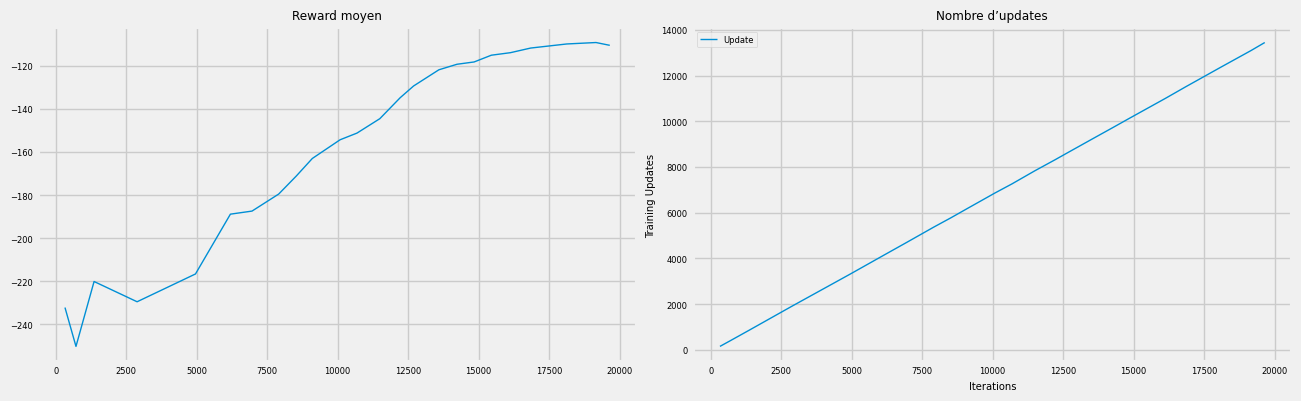

In [16]:
from stable_baselines3 import DQN
import gymnasium as gym
import pandas as pds
from pathlib import Path

base_Log_dir = Path("/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_APPAUT/TP4/lunarLander/log/sb3_log")
progress_filePath = base_Log_dir / "progress.csv"

env = gym.make(
               'LunarLander-v3',
               render_mode="rgb_array_list",
               gravity = -10.0,
               enable_wind = True,
               wind_power = 15.0,
               turbulence_power = 1.5,
               max_episode_steps=1000,
               )

device = device_function()
model = DQN("MlpPolicy", env, device=device,verbose=1,**kwargs_Lunar_DQN)
learn_function(env,model,str(base_Log_dir),kwargs_Lunar_DQN,20000)
log = pds.read_csv(str(progress_filePath))
display_curve(log)

In [17]:
from pathlib import Path

base_dir = Path("/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_APPAUT/TP4/lunarLander")
filePath = base_dir / "LunarLander_DQN_movie.mp4"

images = prediction(env, model)
make_video(images,str(filePath))
play_video(str(filePath),width=800)
#AssertionError(True)

100%|██████████| 234/234 [00:00<00:00, 1920.36it/s]


### __`Changement d'algorithme DQN vs PPO `__ 

`PPO (Proximal Policy Optimization) est un algorithme on‑policy` :    
- Signifie qu’il améliore la politique en utilisant les épisodes issues de l'apprentissage en cours. 
- Il ne recycle pas longtemps les anciennes données comme le fait DQN.
 
`DQN (Deep Q-Network) est un algorithme off-policy` :       
- Signifie qu'il recycle les anciennes données issue du tampon de relecture pour rejeu.

`Paramètres de l'algorithme PPO`
 
__Le clipping__ 

 - Dans PPO, le clipping est une façon de limiter l’ampleur de la mise à jour de la politique à chaque pas de gradien

 - $\large r_t(θ)= \LARGE \frac{π_{θ}(a_t∣s_t)}{π_{θ_{old}}(a_t∣s_t)}$ et définit la partie “clippée” de l’objectif comme

$r_t(θ)$ est le ratio entre la nouvelle politique et l’ancienne pour l’action réellement prise au temps t.   
 - $r_t(θ)≈1$ : la nouvelle politique une probabilité $a_t$ équivalente à l’ancienne peu de changement.
 - $r_t(θ)>1$ : la nouvelle politique augmente la probabilité de $a_t$
 - $r_t(θ)<1$ : la nouvelle politique la diminue.

PPO utilise ce ratio dans le terme clippé pour empêcher $r_t(θ)$ de s’éloigner trop de 1, donc pour limiter les écarts que la politique génère d’une mise à jour à l’autre. 

$L^{clip}(\theta)  = \mathbb{E}\left[ \min(r_t(\theta)A_t, clip((r_t(\theta), 1- \large\epsilon,\small 1+\large \epsilon) \small A_t \right] $  

- $ \small clip(r, 1 - \large \epsilon, \small 1 + \large \epsilon) \small \text{ remplacer r par } \max(1-\large \epsilon, \small \min(r,1+ \large \epsilon))$
- Typiquement $\large \epsilon ≈$ 0.1 ou 0.2.

_Mécanisme de clipping sert de protection_ : 

- Limite les modifications brutales de la probabilité, évitant des pas de gradient dangereux.
- Ce compromis, impose une mise à jour contrainte.  
- Il est plus marquée que dans les approches les plus conservatrices.   
- PPO est un algorithme simple et robuste pour des tâches réelles exigeantes, notamment en robotique.   

__n_steps__    

 - Nombre d'étapes à exécuter pour chaque environnement par mise à jour
 - Correspond à la taille du tampon de déploiement est n_steps * n_envs, 
 - n_envs est le nombre de copies d'environnement exécutées en parallèle.

__ent_coef`__

 - Coefficient de l’entropie dans la fonction de perte
 - Si la politique se fige trop tôt, essaie une petite entropie, par exemple 0.01 ou 0.001.


__Essayez de modifer les paramètres pour voir le changement de comportement du modèle.__

Output()

Using mps device


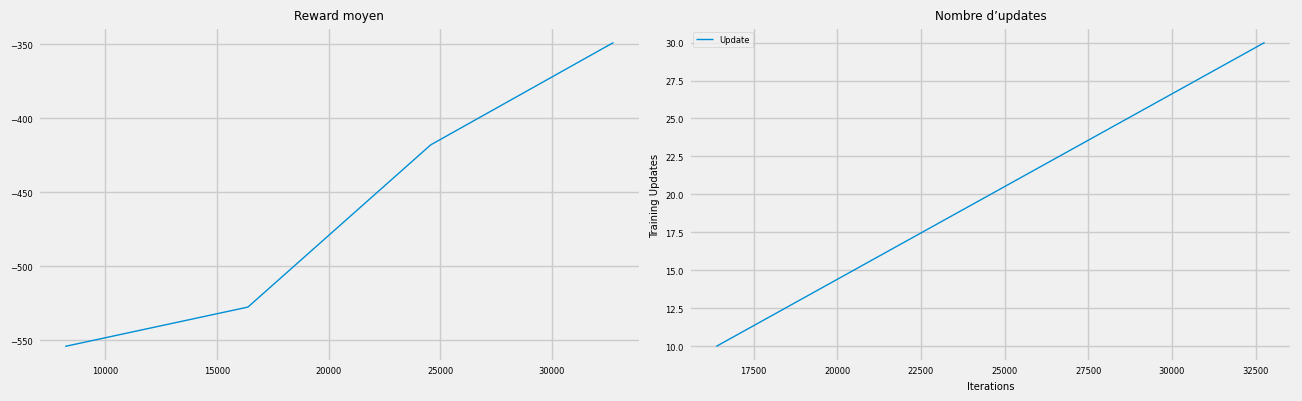

In [67]:
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3 import PPO

kwargsPPO = {
    "learning_rate" : 3e-4,  # taux d’apprentissage de l’optimiseur (Adam), contrôle la taille des pas de gradient
    "n_steps" : 512,         # nombre de pas de collecte de données avant chaque mise à jour
    "batch_size" : 128,      # Taille des mini-batchs pour l’optimisation
    "n_epochs" : 10,         # nombre de passes sur le même rollout.
    "gamma" : 0.99,          # facteur d’actualisation des récompenses futures
    "gae_lambda" : 0.95,     # Facteur de compromis entre biais et variance pour l'estimateur d'avantage généralisé    
    "clip_range" : 0.2,     # Paramètre de découpage, peut être une fonction de la progression restante (de 1 à 0).
    "ent_coef" : 0.005,      # coefficient de l’entropie dans la fonction de perte
    "vf_coef" : 0.5,         # coefficient de la fonction de valeur dans la fonction de perte
    "max_grad_norm" : 0.5,    # norme maximale pour le clipping des gradients
    "policy_kwargs":dict(net_arch=[8,128,128,8]),
}

lunar_base_Log_dir_ppo = Path("/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_APPAUT/TP4/lunarLander/log/sb3_ppo_log")
lunar_progress_filePath_ppo = lunar_base_Log_dir_ppo / "progress.csv"

# nombre d’environnements parallèles
n_envs = 16

def make_env():
    return gym.make(
               'LunarLander-v3',
               render_mode="rgb_array_list",
               gravity = -3.0,
               enable_wind = True,
               wind_power = 15.0,
               turbulence_power = 1.5,
               max_episode_steps=1000,
               )
    
device = device_function()
vec_env = make_vec_env(make_env, n_envs=n_envs)
model = PPO("MlpPolicy", vec_env, device=device, verbose=1, **kwargsPPO)
learn_function(vec_env,model,str(lunar_base_Log_dir_ppo),kwargsPPO,30000)
log = pds.read_csv(str(lunar_progress_filePath_ppo))
display_curve(log)

In [69]:
from pathlib import Path

base_dir = Path("/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_APPAUT/TP4/lunarLander")
filePath = base_dir / "PPO_movie.mp4"

env = make_env()
images = prediction(env, model)
make_video(images,str(filePath))
play_video(str(filePath),width=800)
#AssertionError(True)

100%|██████████| 165/165 [00:00<00:00, 1764.99it/s]


## __`Changer la récompense`__

L'agent de gymnasium possède un processus permettant de changer la récompense de base.
Ce mécanisme est embarqué avec l'environnement dans une classe spéciale, cf. exemple ci-dessous:

La classe doit intercepter la récompense, et éventuellement le pas qui execute une action si on veut pénaliser spécifiquement des actions.

Essayez de changer la récompense liée à l'usage du moteur par exemple, et regardez les conséquences sur:

 - l'environnement normal par rapport à l'environnement avec gravité plus forte

__`Action 0 : Ne rien faire (do nothing)`__.  

__Aucun moteur n'est allumé__, 
- Le lander est soumis uniquement à la gravité et à l'inertie
- Utile pour économiser du carburant
- Le carburant soit infini dans cet environnement

__`Action 1 : Moteur d'orientation gauche (fire left orientation engine)`__

__Allume le propulseur latéral gauche__, 
- Fait pivoter le lander vers la droite (rotation horaire)
- Coût : -0.03 points par frame​
- Utilisé pour corriger l'angle lorsque le lander penche trop à gauche

__`Action 2 : Moteur principal (fire main engine)`__

__Allume le propulseur principal (orienté vers le bas)__
- Pousse le lander vers le haut, ralentissant la descente
- Coût : -0.3 points par frame​
- Le plus coûteux mais essentiel pour contrôler l'altitude et éviter un crash

__`Action 3 : Moteur d'orientation droit (fire right orientation engine)`__

__Allume le propulseur latéral droit__
- Fait pivoter le lander vers la gauche (rotation anti-horaire)
- Coût : -0.03 points par frame​
- Utilisé pour corriger l'angle lorsque le lander penche trop à droite

__`L'environnement définit un certain nombre de variables observables`__.
:::
`The state is an 8-dimensional vector »`

- state[0] : X (position horizontal) - `cible à 0.0`. 
- state[1] : Y (position hauteur) - `plus haut = mieux`.  
- state[2] : $V_x$ (compsante vitesse horizontale) - `doit être proche de 0 à l'atterrissage`. 
- state[3] : $V_y$ (compsante vitesse verticale) - `doit être faible (descente douce)`.  
- state[4] : $\theta$ (Angle du mobile en radians) - `doit être proche de 0 (vertical)`. 
- state[5] : $\theta'$ (Vitesse angulaire)- `doit être proche de 0`.  
- state[6] : Contact pied gauche `(0 ou 1)`. 
- state[7] : Contact pied droit `(0 ou 1)`. 

:::

:::

L'origine est le point (0,0) qui se trouve eu centre de la cible (les drapeaux).  
 - $\sqrt{x^2+y^2}$ représente la distance du point (x,y) à l’origine.
 - $\sqrt{v_x^2+v_y^2}$ repésente la vitesse du mobile.


:::
 


In [70]:
# Pour donner une idée, voici la forme de la récompense par défaut
def original_reward(state,m_power,s_power):# action2=m_pover, action1+3=s_power
        reward = 0
        shaping = (
            -100 * np.sqrt(state[0] * state[0] + state[1] * state[1])  # x²+y²
            - 100 * np.sqrt(state[2] * state[2] + state[3] * state[3]) # v_x^2+v_y^2
            - 100 * abs(state[4]) # vitesse angulaire
            + 10 * state[6]  # pied 1 posé ou non
            + 10 * state[7]  # pied 2
        )
        reward = shaping

        reward -= (m_power * 0.30)  # less fuel spent is better, about -30 for heuristic landing
        reward -= s_power * 0.03  # moteur latéraux
        return reward


In [87]:
# exemple
obs, _ = env.reset()
original_reward(obs,0,0)

np.float32(-207.6351)

In [88]:
# C'est bien de voir les variation en évaluant sur quelques episodes, et stable_baseline fournit une fonction pour ça
from stable_baselines3.common.evaluation import evaluate_policy

eval_env = gym.make("LunarLander-v3")
mean_reward, std_reward = evaluate_policy(model, eval_env, n_eval_episodes=10, deterministic=True)

print(f"mean_reward={mean_reward:.2f} +/- {std_reward}")

mean_reward=-210.81 +/- 135.891628387993


In [148]:
import numpy as np
import gymnasium as gym
from gymnasium import RewardWrapper

class LL_RewardWrapper(RewardWrapper):
    def __init__(self, env):
        super().__init__(env)
        self.prev_d2 = None
        # coefficients à tuner
        self.w_pos = 0.05   # pénalité distance
        self.w_vel = 0.1   # pénalité vitesse si on se rapproche
        self.w_fuel = 0.2  # pénalité consommation de carburant

    def reset(self, **kwargs):
        #print("Reset LL_RewardWrapper")
        obs, info = self.env.reset(**kwargs)
        x, y, vx, vy, theta, vtheta, leg_l, leg_r = obs
        self.prev_d2 = np.sqrt(x**2 + y**2)
        return obs, info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        x, y, vx, vy, theta, vtheta, leg_l, leg_r = obs
        d2 = x**2 + y**2
        v2 = vx**2 + vy**2
        # 1) pénalité de distance quand on est loin
        reward -= self.w_pos * d2
        # 2) si on se rapproche (d2 diminue), pénaliser la vitesse
        # 3) pénaliser la consommation de carburant
        if d2 < self.prev_d2:
           reward -= (self.w_vel + self.w_fuel) * v2 
        # mettre à jour pour le prochain step
        self.prev_d2 = d2
        #print(f"d2={d2:.2f}, v2={v2:.2f}, reward={reward:.2f}")
        return obs, reward, terminated, truncated, info


Using mps device


Output()

mean_reward=-251.79 +/- 179.35664399516838


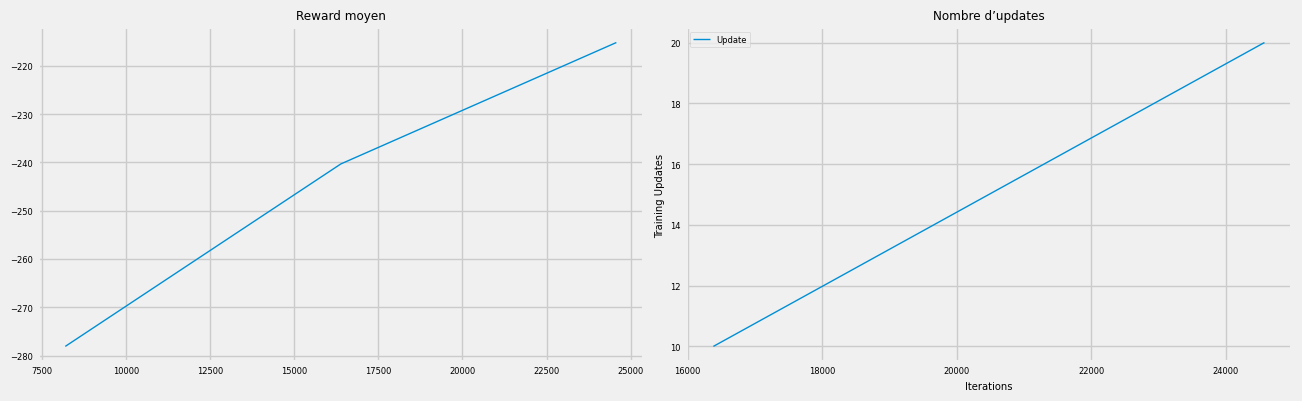

In [155]:
from functools import partial

def make_env(RewardWrapper=True):
    env = gym.make(
        "LunarLander-v3",
        render_mode="rgb_array_list",
        gravity=-10.1,
        enable_wind=True,
        wind_power=15.0,
        turbulence_power=1.5,
        max_episode_steps=1000,
    )
    if RewardWrapper == True: 
       env = LL_RewardWrapper(env)   # << wrapper sur env simple
    return env

device = device_function()
vec_env = make_vec_env(partial(make_env, RewardWrapper=False), n_envs=n_envs)
model = PPO("MlpPolicy", vec_env, device=device, verbose=1, **kwargsPPO)
mean_reward, std_reward = evaluate_policy(model, vec_env, n_eval_episodes=10, deterministic=True)

print(f"mean_reward={mean_reward:.2f} +/- {std_reward}")

learn_function(vec_env,model,str(lunar_base_Log_dir_ppo),kwargsPPO,20000)
log = pds.read_csv(str(lunar_progress_filePath_ppo))
display_curve(log)

In [156]:
from pathlib import Path

base_dir = Path("/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_APPAUT/TP4/lunarLander")
filePath = base_dir / "PPO_movie.mp4"

env = make_env()
images = prediction(env, model)
make_video(images,str(filePath))
play_video(str(filePath),width=800)
#AssertionError(True)

100%|██████████| 480/480 [00:00<00:00, 2181.68it/s]


Using mps device


Output()

mean_reward=-277.52 +/- 173.1577374922338


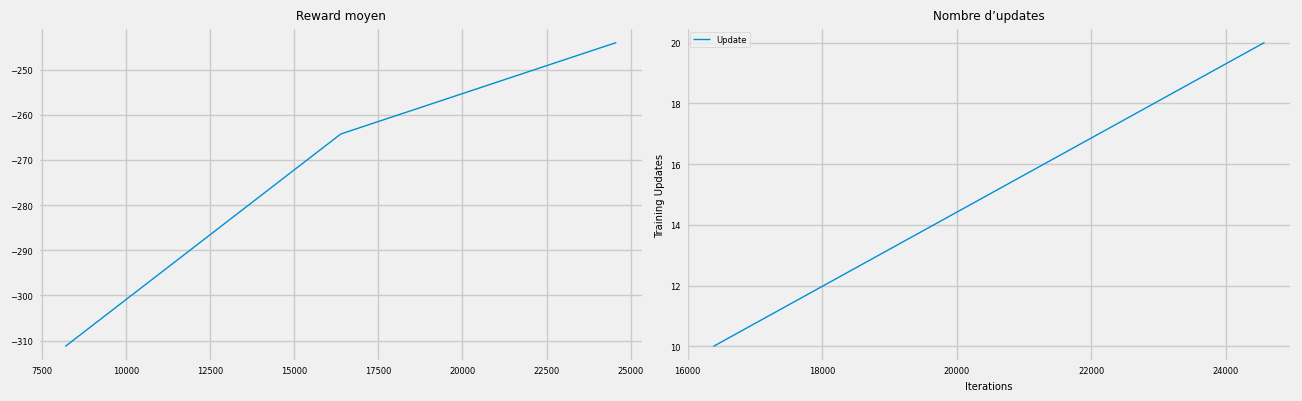

In [157]:
device = device_function()
vec_env = make_vec_env(partial(make_env, RewardWrapper=True), n_envs=n_envs)
model = PPO("MlpPolicy", vec_env, device=device, verbose=1, **kwargsPPO)
mean_reward, std_reward = evaluate_policy(model, vec_env, n_eval_episodes=10, deterministic=True)

print(f"mean_reward={mean_reward:.2f} +/- {std_reward}")

learn_function(vec_env,model,str(lunar_base_Log_dir_ppo),kwargsPPO,20000)
log = pds.read_csv(str(lunar_progress_filePath_ppo))
display_curve(log)

In [159]:
from pathlib import Path

base_dir = Path("/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_APPAUT/TP4/lunarLander")
filePath = base_dir / "PPO_movie.mp4"

env = make_env()
images = prediction(env, model)
make_video(images,str(filePath))
play_video(str(filePath),width=800)
#AssertionError(True)

100%|██████████| 203/203 [00:00<00:00, 1893.36it/s]


## __`Conclusion`__ : 

Les rewards moyens avec ou sans la surcharge de la fonction récompense à l'aide de LL_RewardWrapper sont proches parce que l'on compares deux fonctions de récompense différentes et non pas parce que les comportements sont équivalents, car ils ne le sont manifestement pas puisqu'avec la surchage de la fonction récompense nous arrivons à poser le module à sa cible.

`Les rewards ne sont pas sur la même “échelle”`

 - Sans wrapper, la reward est la reward Gym : position, vitesse, contact jambes, fuel, etc.
 - Avec LL_RewardWrapper, on ajoute/retire des termes (distance, vitesse) à chaque step, 
 - La même trajectoire physique donne une valeur numérique différente.

`Donc pour chaque appel à step`:

 - Nous prennons la reward calculée par l’environnement Gym, auquel on retire $\large w_{pos} * d$,
 - Si l'on se rapproche $\large d < d_{prev}$, nous retirons à nouveau $\large (w_{vel} + w_{fuel}) * v$.

La reward finale renvoyée à PPO est donc : 

 - $\large r_{final} = r_{gym} − w_{pos} d − 1_{d < d_{prev}}  (w_{vel}+w_{fuel})v$